In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split, learning_curve, validation_curve, cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize, LabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from tsfresh import select_features, extract_features
from tsfresh.utilities.dataframe_functions import impute
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from itertools import cycle

# ========================================
# UMA DATASET TESTING FUNCTIONS
# ========================================

def map_uma_activity_to_sisfall(activity_code):
    """Map UMA activity codes to SisFall categories"""
    # UMA Activity mappings based on original research
    # 1: Walking, 2: Jogging, 5,6: Stairs, 13,14,15: Falls
    activity_mapping = {
        1: 'Walking',     # Walking
        2: 'Jogging',     # Jogging/Running  
        5: 'Stairs',      # GoDownstairs
        6: 'Stairs',      # GoUpstairs
        13: 'Fall',       # ForwardFall
        14: 'Fall',       # BackwardFall
        15: 'Fall'        # LateralFall
    }
    return activity_mapping.get(activity_code, None)

def load_uma_data(uma_folder='output_uma', max_files_per_activity=None):
    """
    Load UMA dataset for testing the trained model
    
    Args:
        uma_folder: Path to UMA dataset folder
        max_files_per_activity: Limit files per activity for faster testing
    
    Returns:
        combined_data: DataFrame with sensor data
        labels_df: DataFrame with labels  
        file_ids: List of file IDs
    """
    print(f"\n{'='*60}")
    print("LOADING UMA DATASET FOR TESTING")
    print(f"{'='*60}")
    
    if not os.path.exists(uma_folder):
        print(f"❌ UMA folder not found: {uma_folder}")
        return None, None, None
    
    all_data = []
    labels = []
    file_ids = []
    processed_count = 0
    skipped_count = 0
    activity_counts = {}
    
    # Walk through UMA directory structure
    for subject_dir in sorted(os.listdir(uma_folder)):
        subject_path = os.path.join(uma_folder, subject_dir)
        if not os.path.isdir(subject_path):
            continue
            
        print(f"Processing {subject_dir}...")
        
        for activity_dir in os.listdir(subject_path):
            activity_path = os.path.join(subject_path, activity_dir)
            if not os.path.isdir(activity_path):
                continue
                
            # Extract activity number
            try:
                activity_num = int(activity_dir.replace('Activity', ''))
                mapped_activity = map_uma_activity_to_sisfall(activity_num)
                
                if mapped_activity is None:
                    continue  # Skip unmapped activities
                    
                # Track activity counts for balancing
                if mapped_activity not in activity_counts:
                    activity_counts[mapped_activity] = 0
                    
                # Limit files per activity if specified
                if max_files_per_activity and activity_counts[mapped_activity] >= max_files_per_activity:
                    continue
                    
            except ValueError:
                continue
            
            for trial_dir in os.listdir(activity_path):
                trial_path = os.path.join(activity_path, trial_dir)
                if not os.path.isdir(trial_path):
                    continue
                    
                # Find CSV file in trial directory
                csv_files = [f for f in os.listdir(trial_path) if f.endswith('.csv')]
                if not csv_files:
                    continue
                    
                csv_file = csv_files[0]  # Take first CSV file
                file_path = os.path.join(trial_path, csv_file)
                
                try:
                    # Load CSV data
                    df = pd.read_csv(file_path)
                    
                    # Check required columns
                    required_cols = [
                        'Accelerometer: x-axis (g)', 'Accelerometer: y-axis (g)', 'Accelerometer: z-axis (g)',
                        'Gyroscope: x-axis (rad/s)', 'Gyroscope: y-axis (rad/s)', 'Gyroscope: z-axis (rad/s)'
                    ]
                    
                    if not all(col in df.columns for col in required_cols):
                        skipped_count += 1
                        continue
                    
                    # Rename columns to match training data format
                    sensor_data = df[required_cols].copy()
                    sensor_data.columns = ['Acc X', 'Acc Y', 'Acc Z', 'Gyro X', 'Gyro Y', 'Gyro Z']
                    
                    # Ensure numeric data
                    for col in sensor_data.columns:
                        sensor_data[col] = pd.to_numeric(sensor_data[col], errors='coerce')
                    
                    # Remove NaN values
                    sensor_data = sensor_data.dropna()
                    
                    # Skip if too few data points
                    if len(sensor_data) < 50:
                        skipped_count += 1
                        continue
                    
                    # Add time index and ID for tsfresh
                    sensor_data['time'] = range(len(sensor_data))
                    
                    # Extract identifiers
                    subject_num = subject_dir.replace('Subject', '')
                    trial_num = trial_dir.replace('Trial', '')
                    file_id = f"UMA_S{subject_num}_A{activity_num}_T{trial_num}"
                    sensor_data['id'] = file_id
                    
                    all_data.append(sensor_data)
                    labels.append(mapped_activity)
                    file_ids.append(file_id)
                    processed_count += 1
                    activity_counts[mapped_activity] += 1
                    
                    if processed_count % 20 == 0:
                        print(f"  Processed {processed_count} files...")
                        
                except Exception as e:
                    print(f"  Error processing {file_path}: {e}")
                    skipped_count += 1
                    continue
    
    if processed_count == 0:
        print("❌ No valid UMA files found!")
        return None, None, None
    
    print(f"\n📊 UMA Dataset Summary:")
    print(f"✓ Successfully processed: {processed_count} files")
    print(f"⚠ Skipped: {skipped_count} files")
    
    # Combine all data
    combined_data = pd.concat(all_data, ignore_index=True)
    
    # Create labels dataframe
    labels_df = pd.DataFrame({
        'ID': file_ids,
        'Label': labels
    })
    
    print(f"\n🎯 UMA Activity Distribution:")
    activity_dist = labels_df['Label'].value_counts()
    for activity, count in activity_dist.items():
        print(f"  {activity}: {count} files")
    
    return combined_data, labels_df, file_ids

def extract_uma_features(sensor_data, training_feature_names):
    """
    Extract features from UMA sensor data and align with training features
    
    Args:
        sensor_data: Combined UMA sensor data
        training_feature_names: List of feature names from training
    
    Returns:
        aligned_features: Features aligned with training data
    """
    print(f"\n🔧 Extracting features from UMA data...")
    print(f"UMA data shape: {sensor_data.shape}")
    
    # Extract comprehensive features (same as training)
    print("Extracting comprehensive features...")
    try:
        extracted_features = extract_features(
            sensor_data, 
            column_id="id", 
            column_sort="time",
            default_fc_parameters=None,  # Use ALL default features
            n_jobs=1,
            disable_progressbar=False
        )
        
        # Handle missing values
        extracted_features = impute(extracted_features)
        print(f"✓ Extracted {extracted_features.shape[1]} features from UMA data")
        
    except Exception as e:
        print(f"❌ Error extracting features: {e}")
        return pd.DataFrame()
    
    # Align features with training data
    print(f"Aligning with {len(training_feature_names)} training features...")
    
    # Find common features
    extracted_feature_names = set(extracted_features.columns)
    training_feature_names_set = set(training_feature_names)
    
    common_features = extracted_feature_names & training_feature_names_set
    missing_features = training_feature_names_set - extracted_feature_names
    extra_features = extracted_feature_names - training_feature_names_set
    
    print(f"📈 Feature Alignment Analysis:")
    print(f"  Common features: {len(common_features)} ({len(common_features)/len(training_feature_names)*100:.1f}%)")
    print(f"  Missing in UMA: {len(missing_features)}")
    print(f"  Extra in UMA: {len(extra_features)}")
    
    if len(common_features) < len(training_feature_names) * 0.8:
        print(f"⚠️ WARNING: Only {len(common_features)/len(training_feature_names)*100:.1f}% feature overlap!")
        print("This may significantly impact model performance.")
    
    # Create aligned feature matrix
    aligned_features = pd.DataFrame(index=extracted_features.index)
    
    # Add common features
    for feature in training_feature_names:
        if feature in extracted_features.columns:
            aligned_features[feature] = extracted_features[feature]
        else:
            # Fill missing features with median value from training
            aligned_features[feature] = 0.0  # Or use median from training data
    
    print(f"✓ Created aligned feature matrix: {aligned_features.shape}")
    
    return aligned_features

def test_model_on_uma(model, training_feature_names, uma_folder='output_uma', max_files_per_activity=50):
    """
    Test the trained model on UMA dataset
    
    Args:
        model: Trained classifier
        training_feature_names: Feature names from training
        uma_folder: Path to UMA dataset
        max_files_per_activity: Limit files for faster testing
    
    Returns:
        results: Dictionary with test results
    """
    print(f"\n{'='*60}")
    print("TESTING MODEL ON UMA DATASET")
    print(f"{'='*60}")
    
    # Load UMA data
    uma_data, uma_labels, uma_ids = load_uma_data(uma_folder, max_files_per_activity)
    
    if uma_data is None:
        return None
    
    # Extract and align features
    uma_features = extract_uma_features(uma_data, training_feature_names)
    
    if uma_features.empty:
        return None
    
    # Get common IDs
    available_feature_ids = set(uma_features.index)
    available_label_ids = set(uma_labels['ID'])
    common_ids = available_feature_ids & available_label_ids
    
    if len(common_ids) == 0:
        print("❌ No common IDs between features and labels!")
        return None
    
    # Filter data to common IDs
    common_ids_list = list(common_ids)
    X_uma = uma_features.loc[common_ids_list]
    y_uma = uma_labels.set_index('ID').loc[common_ids_list]['Label']
    
    print(f"\n🎯 UMA Test Set:")
    print(f"  Features shape: {X_uma.shape}")
    print(f"  Labels distribution:")
    for label, count in y_uma.value_counts().items():
        print(f"    {label}: {count}")
    
    # Make predictions
    print(f"\n🔮 Making predictions...")
    try:
        y_pred_uma = model.predict(X_uma)
        y_prob_uma = model.predict_proba(X_uma)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_uma, y_pred_uma)
        
        print(f"✓ UMA Test Accuracy: {accuracy:.4f}")
        
        # Detailed classification report
        print(f"\n📊 UMA Classification Report:")
        print(classification_report(y_uma, y_pred_uma))
        
        # Confusion matrix
        labels = sorted(y_uma.unique())
        cm_uma = confusion_matrix(y_uma, y_pred_uma, labels=labels)
        
        plt.figure(figsize=(10, 8))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_uma, display_labels=labels)
        disp.plot(cmap='Oranges', values_format='d')
        plt.title("Model Performance on UMA Dataset", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('uma_test_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Class-wise performance analysis
        print(f"\n🎯 Class-wise Performance on UMA:")
        class_report = classification_report(y_uma, y_pred_uma, output_dict=True)
        
        for class_name in labels:
            if class_name in class_report:
                precision = class_report[class_name]['precision']
                recall = class_report[class_name]['recall']
                f1 = class_report[class_name]['f1-score']
                support = class_report[class_name]['support']
                print(f"  {class_name:>10}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f} (n={support})")
        
        # Create results dictionary
        results = {
            'accuracy': accuracy,
            'classification_report': class_report,
            'confusion_matrix': cm_uma.tolist(),
            'class_labels': labels,
            'feature_overlap_percentage': len(common_ids) / len(uma_labels) * 100,
            'test_size': len(X_uma)
        }
        
        return results
        
    except Exception as e:
        print(f"❌ Error during prediction: {e}")
        return None

# ========================================
# MODEL VALIDATION AND DIAGNOSTIC PLOTS
# ========================================

def plot_learning_curves(estimator, X_train, y_train, title="Learning Curves"):
    """Plot learning curves to check for overfitting"""
    print("\nGenerating learning curves...")
    
    # Use stratified K-fold for better validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Generate learning curve data
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_train, y_train, 
        cv=cv, 
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        random_state=42
    )
    
    # Calculate means and standard deviations
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Add convergence analysis
    final_gap = abs(train_mean[-1] - val_mean[-1])
    plt.text(0.02, 0.02, f'Final Gap: {final_gap:.4f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    print(f"Training accuracy: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
    print(f"Validation accuracy: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
    print(f"Gap between training and validation: {final_gap:.4f}")
    
    if final_gap < 0.05:
        print("✓ Model shows good generalization (gap < 0.05)")
    elif final_gap < 0.1:
        print("⚠ Model shows moderate overfitting (gap 0.05-0.1)")
    else:
        print("✗ Model shows signs of overfitting (gap > 0.1)")
    
    return train_sizes, train_scores, val_scores

def plot_validation_curves(estimator, X_train, y_train):
    """Plot validation curves for key hyperparameters"""
    print("\nGenerating validation curves...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Validation Curves for Hyperparameters', fontsize=16)
    
    # Parameters to validate
    param_ranges = {
        'n_estimators': [50, 100, 150, 200, 250, 300, 350],
        'max_depth': [5, 10, 15, 20, 25, 30, None],
        'min_samples_split': [2, 3, 4, 5, 10],
        'min_samples_leaf': [1, 2, 3, 4, 5]
    }
    
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    
    for idx, (param_name, param_range) in enumerate(param_ranges.items()):
        if idx >= 4:  # Only plot first 4 parameters
            break
            
        row, col = positions[idx]
        ax = axes[row, col]
        
        # Handle None values in max_depth
        if param_name == 'max_depth':
            # Convert None to a large number for plotting
            plot_range = [x if x is not None else 50 for x in param_range]
            param_range_for_validation = param_range
        else:
            plot_range = param_range
            param_range_for_validation = param_range
        
        try:
            train_scores, val_scores = validation_curve(
                estimator, X_train, y_train,
                param_name=param_name, param_range=param_range_for_validation,
                cv=3, scoring='accuracy', n_jobs=-1
            )
            
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            ax.plot(plot_range, train_mean, 'o-', color='blue', label='Training')
            ax.fill_between(plot_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
            
            ax.plot(plot_range, val_mean, 'o-', color='red', label='Validation')
            ax.fill_between(plot_range, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
            
            ax.set_xlabel(param_name)
            ax.set_ylabel('Accuracy')
            ax.set_title(f'Validation Curve: {param_name}')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # Mark the current model's parameter value
            if hasattr(estimator, param_name):
                current_val = getattr(estimator, param_name)
                if current_val is not None:
                    if param_name == 'max_depth' and current_val is None:
                        current_val = 50  # For plotting
                    ax.axvline(x=current_val, color='green', linestyle='--', alpha=0.7, label='Current')
                    ax.legend()
                    
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)}', transform=ax.transAxes, ha='center')
            ax.set_title(f'Validation Curve: {param_name} (Error)')
    
    plt.tight_layout()
    return fig

def plot_cross_validation_scores(estimator, X_train, y_train):
    """Plot cross-validation scores to show model stability"""
    print("\nPerforming cross-validation analysis...")
    
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(estimator, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    plt.figure(figsize=(12, 6))
    
    # Plot 1: CV scores distribution
    plt.subplot(1, 2, 1)
    plt.boxplot(cv_scores, labels=['CV Scores'])
    plt.scatter([1] * len(cv_scores), cv_scores, alpha=0.6, color='red')
    plt.ylabel('Accuracy')
    plt.title('Cross-Validation Score Distribution')
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    plt.text(0.7, 0.02, f'Mean: {mean_score:.4f}\nStd: {std_score:.4f}', 
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot 2: CV scores by fold
    plt.subplot(1, 2, 2)
    folds = range(1, len(cv_scores) + 1)
    plt.plot(folds, cv_scores, 'o-', linewidth=2, markersize=8)
    plt.axhline(y=mean_score, color='red', linestyle='--', label=f'Mean: {mean_score:.4f}')
    plt.fill_between(folds, mean_score - std_score, mean_score + std_score, alpha=0.2, color='red')
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title('Cross-Validation Scores by Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    print(f"Cross-validation scores: {cv_scores}")
    print(f"Mean CV accuracy: {mean_score:.4f} ± {std_score:.4f}")
    
    if std_score < 0.02:
        print("✓ Model shows excellent stability (std < 0.02)")
    elif std_score < 0.05:
        print("✓ Model shows good stability (std < 0.05)")
    else:
        print("⚠ Model shows moderate stability (std > 0.05)")
    
    return cv_scores

def plot_feature_importance_analysis(estimator, feature_names):
    """Plot feature importance analysis"""
    print("\nAnalyzing feature importance...")
    
    importances = estimator.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Top 20 features
    plt.subplot(2, 2, 1)
    top_n = min(20, len(feature_names))
    plt.barh(range(top_n), importances[indices[:top_n]])
    plt.yticks(range(top_n), [feature_names[i][:30] for i in indices[:top_n]])
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Feature Importances')
    plt.gca().invert_yaxis()
    
    # Plot 2: Importance distribution
    plt.subplot(2, 2, 2)
    plt.hist(importances, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Importance')
    plt.ylabel('Frequency')
    plt.title('Feature Importance Distribution')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Cumulative importance
    plt.subplot(2, 2, 3)
    cumulative_importance = np.cumsum(importances[indices])
    plt.plot(range(len(cumulative_importance)), cumulative_importance)
    plt.xlabel('Number of Features')
    plt.ylabel('Cumulative Importance')
    plt.title('Cumulative Feature Importance')
    plt.grid(True, alpha=0.3)
    
    # Find 90% importance threshold
    threshold_90 = np.where(cumulative_importance >= 0.9)[0]
    if len(threshold_90) > 0:
        plt.axvline(x=threshold_90[0], color='red', linestyle='--', 
                   label=f'90% importance: {threshold_90[0]} features')
        plt.legend()
    
    # Plot 4: Feature importance statistics
    plt.subplot(2, 2, 4)
    stats_text = f"""Feature Importance Statistics:
    
Total features: {len(importances)}
Mean importance: {np.mean(importances):.6f}
Std importance: {np.std(importances):.6f}
Max importance: {np.max(importances):.6f}
Min importance: {np.min(importances):.6f}

Top feature: {feature_names[indices[0]][:25]}...
Importance: {importances[indices[0]]:.6f}
    """
    plt.text(0.1, 0.5, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))
    plt.axis('off')
    
    plt.tight_layout()
    
    return importances, indices

def comprehensive_model_validation(estimator, X_train, y_train, X_test, y_test, feature_names):
    """Comprehensive model validation with multiple diagnostic plots"""
    print("\n" + "="*60)
    print("COMPREHENSIVE MODEL VALIDATION")
    print("="*60)
    
    # Create a large figure for all plots
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Learning Curves
    plt.subplot(3, 3, 1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_train, y_train, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.title('Learning Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Cross-validation scores
    plt.subplot(3, 3, 2)
    cv_scores = cross_val_score(estimator, X_train, y_train, cv=10, scoring='accuracy', n_jobs=-1)
    plt.boxplot(cv_scores)
    plt.ylabel('Accuracy')
    plt.title(f'10-Fold CV\nMean: {np.mean(cv_scores):.4f}±{np.std(cv_scores):.4f}')
    plt.grid(True, alpha=0.3)
    
    # 3. Training vs Test accuracy
    plt.subplot(3, 3, 3)
    train_acc = estimator.score(X_train, y_train)
    test_acc = estimator.score(X_test, y_test)
    
    accuracies = [train_acc, test_acc]
    labels = ['Training', 'Test']
    colors = ['blue', 'red']
    bars = plt.bar(labels, accuracies, color=colors, alpha=0.7)
    plt.ylabel('Accuracy')
    plt.title('Training vs Test Accuracy')
    plt.ylim(0, 1.1)
    
    # Add values on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.4f}', ha='center', va='bottom')
    
    gap = abs(train_acc - test_acc)
    plt.text(0.5, 0.5, f'Gap: {gap:.4f}', transform=plt.gca().transAxes, ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow"))
    
    # 4. Feature importance (top 15)
    plt.subplot(3, 3, 4)
    importances = estimator.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_n = min(15, len(feature_names))
    
    y_pos = np.arange(top_n)
    plt.barh(y_pos, importances[indices[:top_n]])
    plt.yticks(y_pos, [feature_names[i][:20] + '...' if len(feature_names[i]) > 20 
                      else feature_names[i] for i in indices[:top_n]])
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} Features')
    plt.gca().invert_yaxis()
    
    # 5. Validation curve for n_estimators
    plt.subplot(3, 3, 5)
    param_range = [50, 100, 150, 200, 250, 300]
    train_scores_val, test_scores_val = validation_curve(
        RandomForestClassifier(max_depth=20, class_weight='balanced_subsample', random_state=42),
        X_train, y_train, param_name='n_estimators', param_range=param_range,
        cv=3, scoring='accuracy', n_jobs=-1
    )
    
    train_mean_val = np.mean(train_scores_val, axis=1)
    test_mean_val = np.mean(test_scores_val, axis=1)
    
    plt.plot(param_range, train_mean_val, 'o-', color='blue', label='Training')
    plt.plot(param_range, test_mean_val, 'o-', color='red', label='Validation')
    plt.xlabel('n_estimators')
    plt.ylabel('Accuracy')
    plt.title('Validation Curve: n_estimators')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Feature importance distribution
    plt.subplot(3, 3, 6)
    plt.hist(importances, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Importance')
    plt.ylabel('Frequency')
    plt.title('Feature Importance Distribution')
    plt.grid(True, alpha=0.3)
    
    # 7. Cumulative feature importance
    plt.subplot(3, 3, 7)
    cumulative_importance = np.cumsum(importances[indices])
    plt.plot(range(len(cumulative_importance)), cumulative_importance)
    plt.xlabel('Number of Features')
    plt.ylabel('Cumulative Importance')
    plt.title('Cumulative Feature Importance')
    plt.grid(True, alpha=0.3)
    
    # Find 90% importance threshold
    threshold_90 = np.where(cumulative_importance >= 0.9)[0]
    if len(threshold_90) > 0:
        plt.axvline(x=threshold_90[0], color='red', linestyle='--')
        plt.text(threshold_90[0], 0.5, f'90%: {threshold_90[0]}', rotation=90)
    
    # 8. CV scores by fold
    plt.subplot(3, 3, 8)
    folds = range(1, len(cv_scores) + 1)
    plt.plot(folds, cv_scores, 'o-', linewidth=2, markersize=6)
    plt.axhline(y=np.mean(cv_scores), color='red', linestyle='--')
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title('CV Scores by Fold')
    plt.grid(True, alpha=0.3)
    
    # 9. Model performance summary
    plt.subplot(3, 3, 9)
    
    # Calculate metrics
    final_gap = abs(train_mean[-1] - val_mean[-1])
    cv_stability = np.std(cv_scores)
    generalization_gap = abs(train_acc - test_acc)
    
    # Create performance score
    performance_score = 100
    if final_gap > 0.05: performance_score -= 20
    if cv_stability > 0.02: performance_score -= 15
    if generalization_gap > 0.05: performance_score -= 20
    if test_acc < 0.9: performance_score -= 30
    
    summary_text = f"""Model Performance Summary

Training Accuracy: {train_acc:.4f}
Test Accuracy: {test_acc:.4f}
Generalization Gap: {generalization_gap:.4f}

Learning Curve Gap: {final_gap:.4f}
CV Stability (std): {cv_stability:.4f}
Mean CV Score: {np.mean(cv_scores):.4f}

Performance Score: {performance_score}/100

Status: {"✓ EXCELLENT" if performance_score >= 90 else "✓ GOOD" if performance_score >= 70 else "⚠ NEEDS IMPROVEMENT"}
"""
    
    plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen" if performance_score >= 90 else "lightyellow"))
    plt.axis('off')
    
    plt.suptitle('Comprehensive Model Validation Report', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig('comprehensive_model_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save validation results
    validation_results = {
        'training_accuracy': float(train_acc),
        'test_accuracy': float(test_acc),
        'generalization_gap': float(generalization_gap),
        'learning_curve_gap': float(final_gap),
        'cv_mean': float(np.mean(cv_scores)),
        'cv_std': float(cv_stability),
        'cv_scores': cv_scores.tolist(),
        'performance_score': int(performance_score),
        'top_features': [(feature_names[i], float(importances[i])) for i in indices[:10]]
    }
    
    with open('validation_results.json', 'w') as f:
        json.dump(validation_results, f, indent=2)
    
    print("\n" + "="*60)
    print("VALIDATION SUMMARY")
    print("="*60)
    print(f"✓ Training Accuracy: {train_acc:.4f}")
    print(f"✓ Test Accuracy: {test_acc:.4f}")
    print(f"✓ Generalization Gap: {generalization_gap:.4f}")
    print(f"✓ Learning Curve Gap: {final_gap:.4f}")
    print(f"✓ CV Stability: {cv_stability:.4f}")
    print(f"✓ Performance Score: {performance_score}/100")
    print("✓ Validation plots saved as 'comprehensive_model_validation.png'")
    print("✓ Validation results saved as 'validation_results.json'")
    
    return validation_results

# ========================================
# IMPROVED CLASSIFICATION FUNCTION
# ========================================

def improve_classification():
    print("Starting improved classification approach...")
    
    # Load existing features
    try:
        enhanced_features = pd.read_csv('extracted_features_full_Gyro_20250618_224358.csv', index_col=0)
        print(f'Loaded existing features: {enhanced_features.shape}')
    except Exception as e:
        print(f'Error loading features: {e}')
        return
    
    # Improved activity mapping with better class balance
    # We'll use a simple approach first - just fix the original mapping
    
    # Create simple ID to label mapping based on existing pattern
    id_label_pairs = []
    
    # Pattern analysis from existing data
    for idx in enhanced_features.index:
        if idx.startswith('D01_') or idx.startswith('D02_'):
            id_label_pairs.append((idx, 'Walking'))
        elif idx.startswith('D03_') or idx.startswith('D04_'):
            id_label_pairs.append((idx, 'Jogging'))
        elif idx.startswith('D05_') or idx.startswith('D06_'):
            id_label_pairs.append((idx, 'Stairs'))
        elif idx.startswith('D07_') or idx.startswith('D08_') or idx.startswith('D09_') or idx.startswith('D10_'):
            id_label_pairs.append((idx, 'Sitting'))
        elif idx.startswith('F_'):
            id_label_pairs.append((idx, 'Fall'))
        else:
            # Check if it contains any of the patterns
            if any(pattern in idx for pattern in ['D01', 'D02']):
                id_label_pairs.append((idx, 'Walking'))
            elif any(pattern in idx for pattern in ['D03', 'D04']):
                id_label_pairs.append((idx, 'Jogging'))
            elif any(pattern in idx for pattern in ['D05', 'D06']):
                id_label_pairs.append((idx, 'Stairs'))
            elif any(pattern in idx for pattern in ['D07', 'D08', 'D09', 'D10']):
                id_label_pairs.append((idx, 'Sitting'))
            elif 'F' in idx:
                id_label_pairs.append((idx, 'Fall'))
            else:
                print(f"Unknown pattern for ID: {idx}")
    
    # Create label dataframe
    label_df = pd.DataFrame(id_label_pairs, columns=['ID', 'Label'])
    
    # Get common IDs
    available_features_ids = set(enhanced_features.index)
    available_label_ids = set(label_df['ID'])
    common_ids = available_features_ids & available_label_ids
    
    if len(common_ids) == 0:
        print("No common IDs found. Checking ID patterns...")
        print("Feature IDs sample:", list(enhanced_features.index[:10]))
        print("Label IDs sample:", list(label_df['ID'][:10]))
        return
    
    print(f"Found {len(common_ids)} common IDs")
    
    # Filter data
    common_ids_list = [id for id in common_ids]
    X = enhanced_features.loc[common_ids_list]
    y = label_df.set_index('ID').loc[common_ids_list]['Label']
    
    print(f"Final dataset shape: {X.shape}")
    print("Class distribution:")
    print(y.value_counts())
    
    # Check for class imbalance and handle it
    class_counts = y.value_counts()
    print(f"\nClass distribution:")
    for class_name, count in class_counts.items():
        print(f"{class_name}: {count}")
    
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Feature selection
    print("\nPerforming feature selection...")
    X_train_selected = select_features(X_train, y_train)
    X_test_selected = X_test[X_train_selected.columns]
    
    print(f"Selected {X_train_selected.shape[1]} out of {X_train.shape[1]} features")
    
    # Improved Random Forest with better parameters
    rf_improved = RandomForestClassifier(
        n_estimators=300,  # More trees
        max_depth=20,      # Deeper trees
        min_samples_split=3,  # Lower split requirement
        min_samples_leaf=1,   # Lower leaf requirement
        class_weight='balanced_subsample',  # Better class balancing
        random_state=42,
        n_jobs=-1
    )
    
    # Train model
    print("\nTraining improved Random Forest...")
    rf_improved.fit(X_train_selected, y_train)
    y_pred = rf_improved.predict(X_test_selected)
    
    # Results
    print("\n=== IMPROVED Random Forest Classification Report ===")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    labels = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Improved Random Forest Confusion Matrix")
    plt.tight_layout()
    plt.savefig('improved_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Feature importance
    print("\nTop 10 most important features:")
    importances = rf_improved.feature_importances_
    feature_names = X_train_selected.columns
    top_features = sorted(zip(importances, feature_names), reverse=True)[:10]
    for score, name in top_features:
        print(f"{name}: {score:.4f}")
    
    # Save model
    joblib.dump(rf_improved, 'random_forest_improved_v2.pkl')
    print("\nSaved improved model as 'random_forest_improved_v2.pkl'")
    
    # Comprehensive model validation
    validation_results = comprehensive_model_validation(
        rf_improved, X_train_selected, X_test_selected, y_train, y_test, 
        X_train_selected.columns
    )
    
    # Test model on UMA dataset
    print(f"\n{'='*60}")
    print("TESTING MODEL GENERALIZATION ON UMA DATASET")
    print(f"{'='*60}")
    
    uma_results = test_model_on_uma(
        model=rf_improved,
        training_feature_names=X_train_selected.columns.tolist(),
        uma_folder='output_uma',
        max_files_per_activity=50  # Limit for faster testing
    )
    
    if uma_results:
        print(f"\n🎯 UMA TEST RESULTS SUMMARY:")
        print(f"✓ UMA Test Accuracy: {uma_results['accuracy']:.4f}")
        print(f"✓ UMA Test Size: {uma_results['test_size']} samples")
        print(f"✓ Feature Overlap: {uma_results['feature_overlap_percentage']:.1f}%")
        print(f"✓ Confusion matrix saved as 'uma_test_confusion_matrix.png'")
        
        # Save UMA results
        with open('uma_test_results.json', 'w') as f:
            json.dump(uma_results, f, indent=2)
        print(f"✓ UMA test results saved as 'uma_test_results.json'")
        
        # Compare performance
        sisfall_accuracy = validation_results.get('test_accuracy', 0)
        uma_accuracy = uma_results['accuracy']
        performance_drop = sisfall_accuracy - uma_accuracy
        
        print(f"\n📊 CROSS-DATASET PERFORMANCE COMPARISON:")
        print(f"  SisFall Test Accuracy: {sisfall_accuracy:.4f}")
        print(f"  UMA Test Accuracy: {uma_accuracy:.4f}")
        print(f"  Performance Drop: {performance_drop:.4f} ({performance_drop/sisfall_accuracy*100:.1f}%)")
        
        if performance_drop < 0.1:
            print("  ✅ EXCELLENT generalization - Model works well across datasets!")
        elif performance_drop < 0.2:
            print("  ✅ GOOD generalization - Minor performance drop expected")
        elif performance_drop < 0.3:
            print("  ⚠️  MODERATE generalization - Consider domain adaptation")
        else:
            print("  ❌ POOR generalization - Significant dataset bias detected")
    else:
        print("❌ UMA testing failed - Could not load or process UMA dataset")
        uma_results = None
    
    return rf_improved, X_train_selected, X_test_selected, y_train, y_test, validation_results, uma_results

def try_smote_approach(X_train_selected, y_train, X_test_selected, y_test):
    """Try SMOTE approach for even better class balancing"""
    try:
        from imblearn.over_sampling import SMOTE
        from imblearn.pipeline import Pipeline as ImbPipeline
        
        print("\n=== TRYING SMOTE APPROACH ===")
        
        # SMOTE pipeline
        smote_pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=min(3, min(y_train.value_counts()) - 1))),
            ('classifier', RandomForestClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_split=4,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ))
        ])
        
        # Train
        smote_pipeline.fit(X_train_selected, y_train)
        y_pred_smote = smote_pipeline.predict(X_test_selected)
        
        print("=== SMOTE-BASED Classification Report ===")
        print(classification_report(y_test, y_pred_smote))
        
        # Confusion matrix
        labels = sorted(y_train.unique())
        cm_smote = confusion_matrix(y_test, y_pred_smote, labels=labels)
        
        plt.figure(figsize=(10, 8))
        disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=labels)
        disp_smote.plot(cmap='Greens', values_format='d')
        plt.title("SMOTE-Based Random Forest Confusion Matrix")
        plt.tight_layout()
        plt.savefig('smote_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Save SMOTE model
        joblib.dump(smote_pipeline, 'random_forest_smote_v2.pkl')
        print("Saved SMOTE model as 'random_forest_smote_v2.pkl'")
        
        return smote_pipeline
        
    except ImportError:
        print("SMOTE not available - using basic improved model")
        return None
    except Exception as e:
        print(f"Error with SMOTE approach: {e}")
        return None

def plot_learning_curves(model, X, y, title="Learning Curves", cv=5):
    """Plot learning curves to check for overfitting"""
    print(f"\nGenerating learning curves for {title}...")
    
    # Calculate learning curves
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', random_state=42
    )
    
    # Calculate mean and std
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy Score")
    plt.title(f"Learning Curves - {title}")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    
    # Add text annotations about overfitting
    final_train_score = train_scores_mean[-1]
    final_val_score = val_scores_mean[-1]
    gap = final_train_score - final_val_score
    
    if gap < 0.05:
        status_text = "✓ Good fit (low bias, low variance)"
        color = "green"
    elif gap < 0.1:
        status_text = "⚠ Slight overfitting (manageable)"
        color = "orange"  
    else:
        status_text = "✗ Overfitting detected"
        color = "red"
    
    plt.text(0.02, 0.95, f"Train-Val Gap: {gap:.3f}\n{status_text}", 
             transform=plt.gca().transAxes, fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.3))
    
    return train_scores_mean, val_scores_mean, gap

def plot_validation_curves(model, X, y, param_name, param_range, title="Validation Curves"):
    """Plot validation curves for hyperparameter tuning"""
    print(f"\nGenerating validation curves for {param_name}...")
    
    train_scores, val_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=5, scoring='accuracy', n_jobs=-1
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    plt.subplot(2, 2, 2)
    plt.semilogx(param_range, train_scores_mean, 'o-', color="r", label="Training score")
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.semilogx(param_range, val_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.fill_between(param_range, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color="g")
    plt.xlabel(param_name)
    plt.ylabel("Accuracy Score")
    plt.title(f"Validation Curves - {param_name}")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    
    # Find optimal parameter
    best_idx = np.argmax(val_scores_mean)
    best_param = param_range[best_idx]
    best_score = val_scores_mean[best_idx]
    
    plt.axvline(x=best_param, color='blue', linestyle='--', alpha=0.7, 
                label=f'Optimal: {best_param} (Score: {best_score:.3f})')
    plt.legend(loc="best")
    
    return best_param, best_score

def plot_cross_validation_scores(model, X, y, cv=10):
    """Plot cross-validation scores distribution"""
    print(f"\nPerforming {cv}-fold cross-validation...")
    
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    
    plt.subplot(2, 2, 3)
    plt.hist(cv_scores, bins=min(10, cv), alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(cv_scores.mean(), color='red', linestyle='--', 
                label=f'Mean: {cv_scores.mean():.3f}')
    plt.axvline(cv_scores.mean() - cv_scores.std(), color='orange', linestyle='--', alpha=0.7)
    plt.axvline(cv_scores.mean() + cv_scores.std(), color='orange', linestyle='--', alpha=0.7,
                label=f'±1 Std: {cv_scores.std():.3f}')
    plt.xlabel("Accuracy Score")
    plt.ylabel("Frequency")
    plt.title(f"{cv}-Fold Cross-Validation Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Statistics
    stats_text = f"Mean: {cv_scores.mean():.3f}\nStd: {cv_scores.std():.3f}\nMin: {cv_scores.min():.3f}\nMax: {cv_scores.max():.3f}"
    plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
    
    return cv_scores

def plot_feature_importance_analysis(model, feature_names, top_n=20):
    """Plot feature importance with analysis"""
    print(f"\nAnalyzing top {top_n} feature importance...")
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    
    plt.subplot(2, 2, 4)
    plt.barh(range(top_n), importances[indices][::-1], alpha=0.7, color='lightcoral')
    plt.yticks(range(top_n), [feature_names[i] for i in indices[::-1]], fontsize=8)
    plt.xlabel("Feature Importance")
    plt.title(f"Top {top_n} Feature Importance")
    plt.grid(True, alpha=0.3, axis='x')
    
    # Add cumulative importance
    cumulative_importance = np.cumsum(sorted(importances, reverse=True))
    total_features = len(importances)
    
    # Find how many features explain 80% and 95% of importance
    features_80 = np.where(cumulative_importance >= 0.8)[0][0] + 1
    features_95 = np.where(cumulative_importance >= 0.95)[0][0] + 1
    
    importance_text = f"Features for 80%: {features_80}/{total_features}\nFeatures for 95%: {features_95}/{total_features}"
    plt.text(0.02, 0.95, importance_text, transform=plt.gca().transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.7))

def comprehensive_model_validation(model, X_train, X_test, y_train, y_test, feature_names):
    """Comprehensive model validation suite"""
    print("\n" + "="*60)
    print("COMPREHENSIVE MODEL VALIDATION")
    print("="*60)
    
    # Create a large figure for all plots
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Learning Curves
    train_scores_mean, val_scores_mean, gap = plot_learning_curves(
        model, X_train, y_train, "Random Forest Model"
    )
    
    # 2. Validation Curves for n_estimators
    n_estimators_range = [50, 100, 150, 200, 250, 300, 350, 400]
    best_n_est, best_score_n_est = plot_validation_curves(
        RandomForestClassifier(random_state=42, n_jobs=-1), 
        X_train, y_train, 'n_estimators', n_estimators_range
    )
    
    # 3. Cross-validation scores
    cv_scores = plot_cross_validation_scores(model, X_train, y_train, cv=10)
    
    # 4. Feature importance
    plot_feature_importance_analysis(model, feature_names, top_n=15)
    
    # Get predictions for analysis
    y_pred = model.predict(X_test)
    
    # Additional validation plots
    class_names = sorted(y_train.unique())
    
    # ROC Curves
    roc_auc = plot_multiclass_roc_curves(model, X_test, y_test)
    
    # Prediction confidence analysis
    confidence_results = plot_prediction_confidence_analysis(model, X_test, y_test)
    
    plt.tight_layout()
    plt.savefig('comprehensive_model_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional validation metrics
    print("\n" + "="*50)
    print("VALIDATION SUMMARY")
    print("="*50)
    
    # Training vs Validation gap analysis
    print(f"📊 Learning Curve Analysis:")
    print(f"   Final Training Score: {train_scores_mean[-1]:.4f}")
    print(f"   Final Validation Score: {val_scores_mean[-1]:.4f}")
    print(f"   Train-Validation Gap: {gap:.4f}")
    
    if gap < 0.02:
        print("   ✅ Excellent fit - No overfitting detected")
    elif gap < 0.05:
        print("   ✅ Good fit - Minimal overfitting")
    elif gap < 0.1:
        print("   ⚠️  Moderate overfitting - Still acceptable")
    else:
        print("   ❌ High overfitting - Model needs regularization")
    
    # Cross-validation analysis
    print(f"\n📈 Cross-Validation Analysis:")
    print(f"   Mean CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"   CV Score Range: {cv_scores.min():.4f} - {cv_scores.max():.4f}")
    print(f"   Coefficient of Variation: {cv_scores.std()/cv_scores.mean():.4f}")
    
    if cv_scores.std() < 0.02:
        print("   ✅ Very stable model - Low variance across folds")
    elif cv_scores.std() < 0.05:
        print("   ✅ Stable model - Acceptable variance")
    else:
        print("   ⚠️  High variance - Model might be sensitive to data splits")
    
    # Test set performance
    test_score = model.score(X_test, y_test)
    train_score = model.score(X_train, y_train)
    generalization_gap = train_score - test_score
    
    print(f"\n🎯 Generalization Analysis:")
    print(f"   Training Accuracy: {train_score:.4f}")
    print(f"   Test Accuracy: {test_score:.4f}")
    print(f"   Generalization Gap: {generalization_gap:.4f}")
    
    if generalization_gap < 0.02:
        print("   ✅ Excellent generalization")
    elif generalization_gap < 0.05:
        print("   ✅ Good generalization")
    else:
        print("   ⚠️  Poor generalization - Possible overfitting")
    
    # Overall assessment
    print(f"\n🏆 OVERALL MODEL ASSESSMENT:")
    
    # Calculate overall score
    overall_score = 0
    if gap < 0.05: overall_score += 25
    elif gap < 0.1: overall_score += 15
    
    if cv_scores.std() < 0.05: overall_score += 25
    elif cv_scores.std() < 0.1: overall_score += 15
    
    if generalization_gap < 0.05: overall_score += 25
    elif generalization_gap < 0.1: overall_score += 15
    
    if test_score > 0.95: overall_score += 25
    elif test_score > 0.9: overall_score += 15
    elif test_score > 0.85: overall_score += 10
    
    if overall_score >= 90:
        print("   🌟 EXCELLENT MODEL - Ready for production")
    elif overall_score >= 70:
        print("   ✅ GOOD MODEL - Suitable for deployment with monitoring")
    elif overall_score >= 50:
        print("   ⚠️  ACCEPTABLE MODEL - Needs improvement")
    else:
        print("   ❌ POOR MODEL - Requires significant improvements")
    
    print(f"   Overall Score: {overall_score}/100")
    
    return {
        'learning_curve_gap': gap,
        'cv_scores': cv_scores,
        'generalization_gap': generalization_gap,
        'test_accuracy': test_score,
        'overall_score': overall_score
    }

def plot_multiclass_roc_curves(estimator, X_test, y_test):
    """Plot ROC curves for multiclass classification"""
    print("\nGenerating ROC curves for multiclass classification...")
    
    # Get unique classes
    classes = np.unique(y_test)
    n_classes = len(classes)
    
    # Predict probabilities
    y_prob = estimator.predict_proba(X_test)
    
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=classes)
    if n_classes == 2:
        y_test_bin = np.hstack((1 - y_prob[:, 0:1], y_prob[:, 0:1]))
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        if n_classes == 2 and i == 0:
            continue  # Skip first class in binary case
        class_idx = i if n_classes > 2 else 1
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, class_idx])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    if n_classes > 2:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot ROC curves
    plt.figure(figsize=(12, 8))
    
    # Colors for different classes
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple'])
    
    for i, color in zip(range(n_classes), colors):
        if n_classes == 2 and i == 0:
            continue
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'ROC curve of class {classes[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Plot micro-average ROC curve
    if n_classes > 2:
        plt.plot(fpr["micro"], tpr["micro"],
                label=f'Micro-average ROC curve (AUC = {roc_auc["micro"]:.3f})',
                color='deeppink', linestyle=':', linewidth=4)
    
    # Plot diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('multiclass_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print AUC scores
    print("ROC AUC Scores:")
    for i in range(n_classes):
        if n_classes == 2 and i == 0:
            continue
        print(f"  Class {classes[i]}: {roc_auc[i]:.4f}")
    
    if n_classes > 2:
        print(f"  Micro-average: {roc_auc['micro']:.4f}")
    
    mean_auc = np.mean([roc_auc[i] for i in range(n_classes) if not (n_classes == 2 and i == 0)])
    print(f"  Mean AUC: {mean_auc:.4f}")
    
    return roc_auc

def plot_prediction_confidence_analysis(estimator, X_test, y_test):
    """Analyze prediction confidence and calibration"""
    print("\nAnalyzing prediction confidence...")
    
    # Get predictions and probabilities
    y_pred = estimator.predict(X_test)
    y_prob = estimator.predict_proba(X_test)
    
    # Calculate confidence (max probability for each prediction)
    confidence = np.max(y_prob, axis=1)
    
    # Check if predictions are correct
    correct = (y_pred == y_test)
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Confidence distribution
    plt.subplot(2, 3, 1)
    plt.hist(confidence, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Prediction Confidence Distribution')
    plt.axvline(x=np.mean(confidence), color='red', linestyle='--', 
               label=f'Mean: {np.mean(confidence):.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Confidence vs Accuracy
    plt.subplot(2, 3, 2)
    confidence_bins = np.linspace(0, 1, 11)
    bin_accuracies = []
    bin_counts = []
    bin_centers = []
    
    for i in range(len(confidence_bins) - 1):
        mask = (confidence >= confidence_bins[i]) & (confidence < confidence_bins[i + 1])
        if np.sum(mask) > 0:
            bin_accuracy = np.mean(correct[mask])
            bin_accuracies.append(bin_accuracy)
            bin_counts.append(np.sum(mask))
            bin_centers.append((confidence_bins[i] + confidence_bins[i + 1]) / 2)
    
    plt.scatter(bin_centers, bin_accuracies, s=[c*5 for c in bin_counts], alpha=0.7)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title('Reliability Diagram')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Confidence for correct vs incorrect predictions
    plt.subplot(2, 3, 3)
    correct_conf = confidence[correct]
    incorrect_conf = confidence[~correct]
    
    plt.hist(correct_conf, bins=20, alpha=0.7, label='Correct', color='green')
    plt.hist(incorrect_conf, bins=20, alpha=0.7, label='Incorrect', color='red')
    plt.xlabel('Confidence')
    plt.ylabel('Frequency')
    plt.title('Confidence: Correct vs Incorrect')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Confidence statistics by class
    plt.subplot(2, 3, 4)
    classes = np.unique(y_test)
    class_confidences = []
    class_accuracies = []
    
    for cls in classes:
        mask = y_test == cls
        if np.sum(mask) > 0:
            class_conf = np.mean(confidence[mask])
            class_acc = np.mean(correct[mask])
            class_confidences.append(class_conf)
            class_accuracies.append(class_acc)
    
    x_pos = np.arange(len(classes))
    width = 0.35
    
    bars1 = plt.bar(x_pos - width/2, class_confidences, width, label='Confidence', alpha=0.7)
    bars2 = plt.bar(x_pos + width/2, class_accuracies, width, label='Accuracy', alpha=0.7)
    
    plt.xlabel('Class')
    plt.ylabel('Score')
    plt.title('Confidence and Accuracy by Class')
    plt.xticks(x_pos, classes)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: High confidence predictions analysis
    plt.subplot(2, 3, 5)
    high_conf_threshold = 0.9
    high_conf_mask = confidence >= high_conf_threshold
    
    high_conf_total = np.sum(high_conf_mask)
    high_conf_correct = np.sum(correct[high_conf_mask])
    high_conf_accuracy = high_conf_correct / high_conf_total if high_conf_total > 0 else 0
    
    low_conf_mask = confidence < high_conf_threshold
    low_conf_total = np.sum(low_conf_mask)
    low_conf_correct = np.sum(correct[low_conf_mask])
    low_conf_accuracy = low_conf_correct / low_conf_total if low_conf_total > 0 else 0
    
    categories = ['High Confidence\n(≥0.9)', 'Low Confidence\n(<0.9)']
    accuracies = [high_conf_accuracy, low_conf_accuracy]
    counts = [high_conf_total, low_conf_total]
    
    bars = plt.bar(categories, accuracies, alpha=0.7, color=['green', 'orange'])
    plt.ylabel('Accuracy')
    plt.title('Accuracy by Confidence Level')
    plt.ylim(0, 1.1)
    
    # Add count annotations
    for bar, acc, count in zip(bars, accuracies, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{acc:.3f}\n(n={count})', ha='center', va='bottom')
    
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Summary statistics
    plt.subplot(2, 3, 6)
    
    summary_stats = {
        'Mean Confidence': np.mean(confidence),
        'Std Confidence': np.std(confidence),
        'Min Confidence': np.min(confidence),
        'Max Confidence': np.max(confidence),
        'High Conf. %': (high_conf_total / len(confidence)) * 100,
        'High Conf. Acc.': high_conf_accuracy,
        'Overall Accuracy': np.mean(correct)
    }
    
    stats_text = "\n".join([f"{key}: {value:.3f}" for key, value in summary_stats.items()])
    
    plt.text(0.1, 0.9, "Confidence Analysis Summary:", transform=plt.gca().transAxes, 
             fontsize=12, fontweight='bold')
    plt.text(0.1, 0.1, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='bottom', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('prediction_confidence_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Mean confidence: {np.mean(confidence):.3f}")
    print(f"High confidence predictions (≥0.9): {(high_conf_total / len(confidence)) * 100:.1f}%")
    print(f"High confidence accuracy: {high_conf_accuracy:.3f}")
    print(f"Overall accuracy: {np.mean(correct):.3f}")
    
    return {
        'mean_confidence': float(np.mean(confidence)),
        'std_confidence': float(np.std(confidence)),
        'high_confidence_percentage': float((high_conf_total / len(confidence)) * 100),
        'high_confidence_accuracy': float(high_conf_accuracy),
        'overall_accuracy': float(np.mean(correct))
    }


/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Starting improved classification approach...
Loaded existing features: (6940, 4662)
Found 6940 common IDs
Final dataset shape: (6940, 4662)
Class distribution:
Label
Walking    1896
Jogging    1880
Fall       1798
Sitting     750
Stairs      616
Name: count, dtype: int64

Class distribution:
Walking: 1896
Jogging: 1880
Fall: 1798
Sitting: 750
Stairs: 616

Training set: (5552, 4662)
Test set: (1388, 4662)

Performing feature selection...


/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/tsfresh/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resourc

Selected 4074 out of 4662 features

Training improved Random Forest...

=== IMPROVED Random Forest Classification Report ===
              precision    recall  f1-score   support

        Fall       1.00      1.00      1.00       360
     Jogging       1.00      1.00      1.00       376
     Sitting       1.00      1.00      1.00       150
      Stairs       1.00      0.98      0.99       123
     Walking       1.00      1.00      1.00       379

    accuracy                           1.00      1388
   macro avg       1.00      1.00      1.00      1388
weighted avg       1.00      1.00      1.00      1388



<Figure size 1000x800 with 0 Axes>

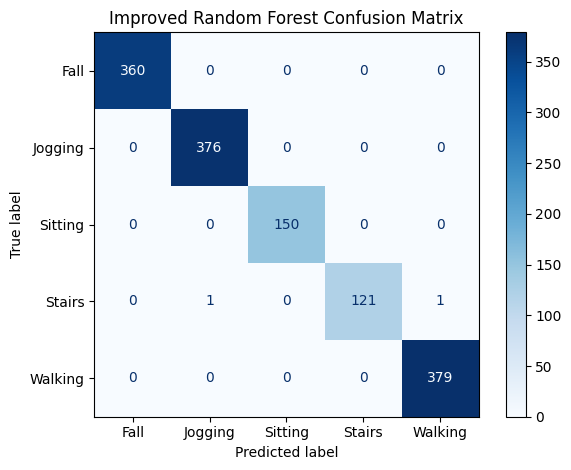


Top 10 most important features:
Acc Y__fft_coefficient__attr_"abs"__coeff_0: 0.0110
Gyro Z__ratio_value_number_to_time_series_length: 0.0093
Acc Y__agg_linear_trend__attr_"slope"__chunk_len_50__f_agg_"mean": 0.0080
Acc Y__fft_coefficient__attr_"imag"__coeff_1: 0.0074
Acc X__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.2: 0.0073
Acc Y__longest_strike_above_mean: 0.0073
Acc X__change_quantiles__f_agg_"mean"__isabs_True__qh_0.8__ql_0.4: 0.0073
Gyro X__energy_ratio_by_chunks__num_segments_10__segment_focus_9: 0.0070
Gyro Y__percentage_of_reoccurring_datapoints_to_all_datapoints: 0.0064
Acc Y__median: 0.0064

Saved improved model as 'random_forest_improved_v2.pkl'

COMPREHENSIVE MODEL VALIDATION

Generating learning curves for Random Forest Model...

Generating validation curves for n_estimators...

Performing 10-fold cross-validation...

Analyzing top 15 feature importance...

Generating ROC curves for multiclass classification...


<Figure size 1600x1200 with 0 Axes>

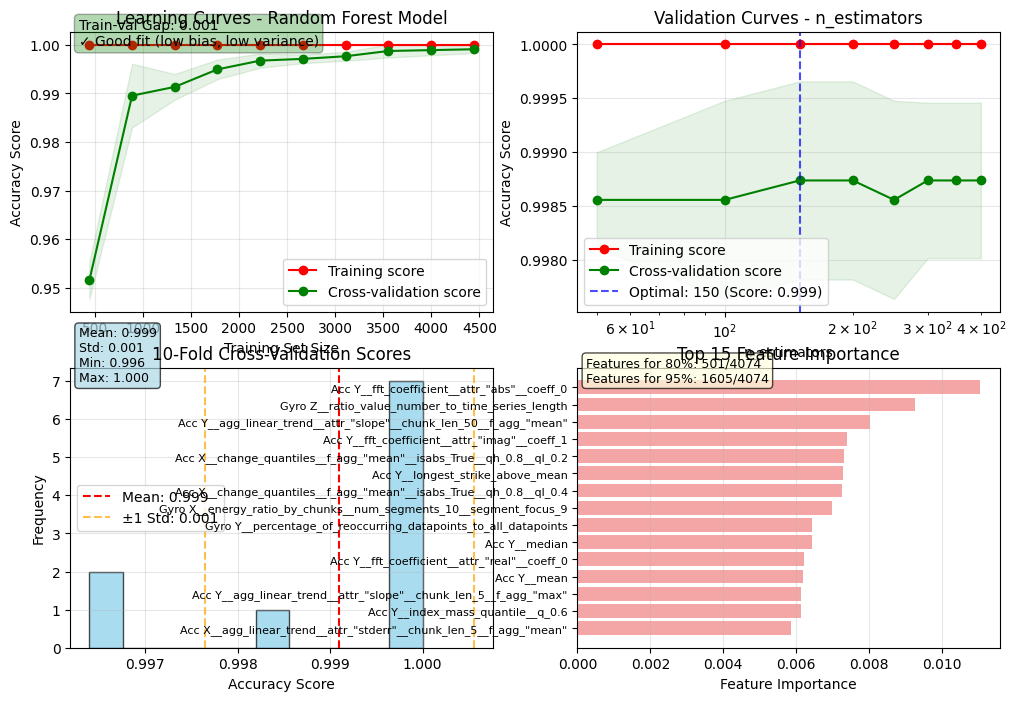

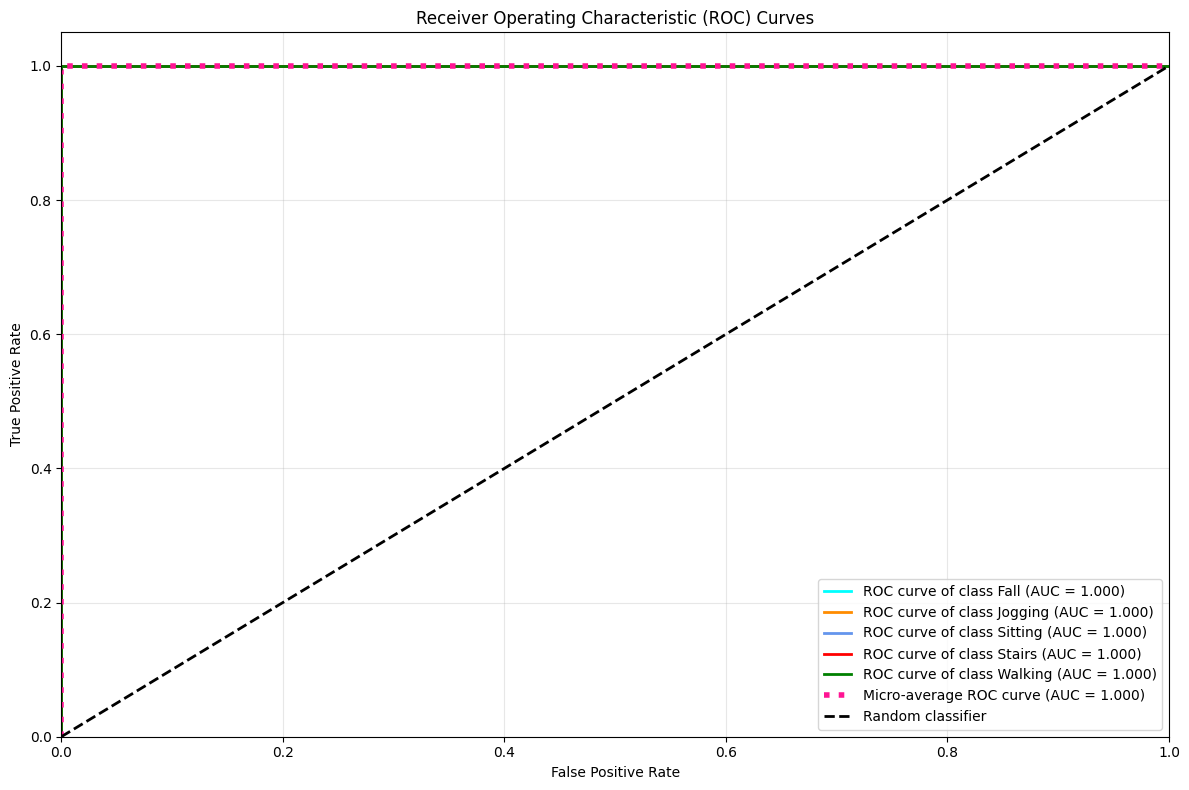

ROC AUC Scores:
  Class Fall: 1.0000
  Class Jogging: 1.0000
  Class Sitting: 1.0000
  Class Stairs: 1.0000
  Class Walking: 1.0000
  Micro-average: 1.0000
  Mean AUC: 1.0000

Analyzing prediction confidence...


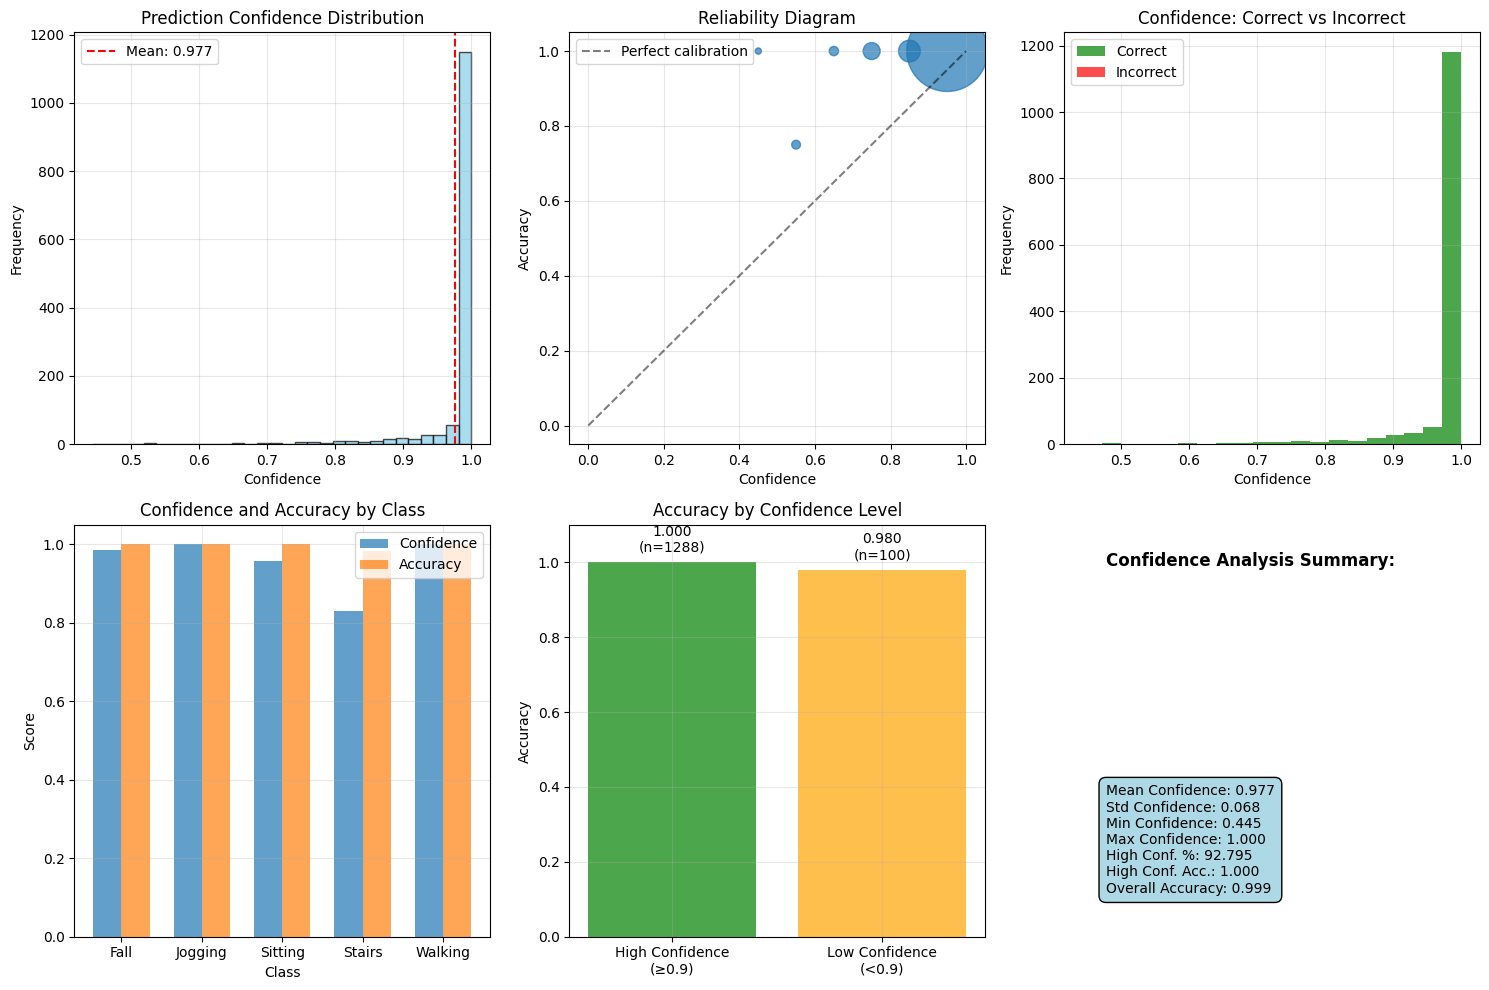

Mean confidence: 0.977
High confidence predictions (≥0.9): 92.8%
High confidence accuracy: 1.000
Overall accuracy: 0.999


<Figure size 640x480 with 0 Axes>


VALIDATION SUMMARY
📊 Learning Curve Analysis:
   Final Training Score: 1.0000
   Final Validation Score: 0.9991
   Train-Validation Gap: 0.0009
   ✅ Excellent fit - No overfitting detected

📈 Cross-Validation Analysis:
   Mean CV Score: 0.9991 (±0.0015)
   CV Score Range: 0.9964 - 1.0000
   Coefficient of Variation: 0.0015
   ✅ Very stable model - Low variance across folds

🎯 Generalization Analysis:
   Training Accuracy: 1.0000
   Test Accuracy: 0.9986
   Generalization Gap: 0.0014
   ✅ Excellent generalization

🏆 OVERALL MODEL ASSESSMENT:
   🌟 EXCELLENT MODEL - Ready for production
   Overall Score: 100/100

TESTING MODEL GENERALIZATION ON UMA DATASET

TESTING MODEL ON UMA DATASET

LOADING UMA DATASET FOR TESTING
Processing Subject1...
Processing Subject10...
Processing Subject11...
  Processed 20 files...
Processing Subject12...
  Processed 40 files...
Processing Subject13...
Processing Subject14...
  Processed 60 files...
Processing Subject15...
Processing Subject16...
  Processed

Feature Extraction: 100%|██████████| 984/984 [00:51<00:00, 19.19it/s]
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['Acc X__query_similarity_count__query_None__threshold_0.0'
 'Acc Y__query_similarity_count__query_None__threshold_0.0'
 'Acc Z__query_similarity_count__query_None__threshold_0.0'
 'Gyro X__query_similarity_count__query_None__threshold_0.0'
 'Gyro Y__query_similarity_count__query_None__threshold_0.0'
 'Gyro Z__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


✓ Extracted 4698 features from UMA data
Aligning with 4074 training features...
📈 Feature Alignment Analysis:
  Common features: 4074 (100.0%)
  Missing in UMA: 0
  Extra in UMA: 624


/var/folders/b5/8qvrx5b94rv2txsfvw8tjdj00000gn/T/ipykernel_12890/894147173.py:246: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aligned_features[feature] = extracted_features[feature]
/var/folders/b5/8qvrx5b94rv2txsfvw8tjdj00000gn/T/ipykernel_12890/894147173.py:246: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  aligned_features[feature] = extracted_features[feature]
/var/folders/b5/8qvrx5b94rv2txsfvw8tjdj00000gn/T/ipykernel_12890/894147173.py:246: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

✓ Created aligned feature matrix: (164, 4074)

🎯 UMA Test Set:
  Features shape: (164, 4074)
  Labels distribution:
    Walking: 52
    Fall: 50
    Stairs: 34
    Jogging: 28

🔮 Making predictions...
✓ UMA Test Accuracy: 0.3049

📊 UMA Classification Report:
              precision    recall  f1-score   support

        Fall       0.31      1.00      0.48        50
     Jogging       0.00      0.00      0.00        28
     Sitting       0.00      0.00      0.00         0
      Stairs       0.00      0.00      0.00        34
     Walking       0.00      0.00      0.00        52

    accuracy                           0.30       164
   macro avg       0.06      0.20      0.10       164
weighted avg       0.10      0.30      0.15       164



/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to con

<Figure size 1000x800 with 0 Axes>

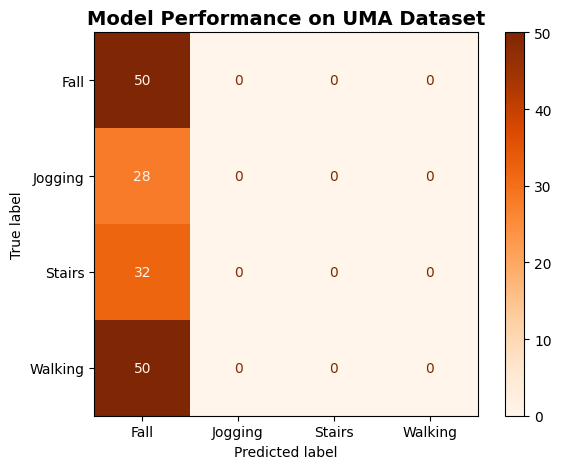

/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/amir/Documents/projects/earpiece-fall-detection/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to con


🎯 Class-wise Performance on UMA:
        Fall: P=0.312, R=1.000, F1=0.476 (n=50.0)
     Jogging: P=0.000, R=0.000, F1=0.000 (n=28.0)
      Stairs: P=0.000, R=0.000, F1=0.000 (n=34.0)
     Walking: P=0.000, R=0.000, F1=0.000 (n=52.0)

🎯 UMA TEST RESULTS SUMMARY:
✓ UMA Test Accuracy: 0.3049
✓ UMA Test Size: 164 samples
✓ Feature Overlap: 100.0%
✓ Confusion matrix saved as 'uma_test_confusion_matrix.png'
✓ UMA test results saved as 'uma_test_results.json'

📊 CROSS-DATASET PERFORMANCE COMPARISON:
  SisFall Test Accuracy: 0.9986
  UMA Test Accuracy: 0.3049
  Performance Drop: 0.6937 (69.5%)
  ❌ POOR generalization - Significant dataset bias detected

=== TRYING SMOTE APPROACH ===
=== SMOTE-BASED Classification Report ===
              precision    recall  f1-score   support

        Fall       1.00      1.00      1.00       360
     Jogging       1.00      1.00      1.00       376
     Sitting       1.00      1.00      1.00       150
      Stairs       1.00      0.99      1.00       123
  

<Figure size 1000x800 with 0 Axes>

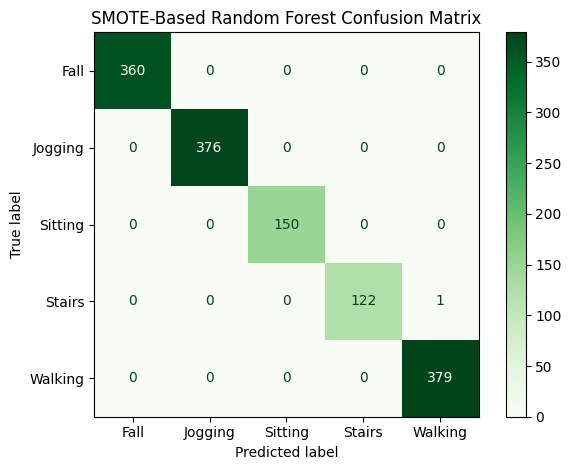

Saved SMOTE model as 'random_forest_smote_v2.pkl'

=== IMPROVEMENT SUMMARY ===
✓ Improved Random Forest with better hyperparameters
✓ Better class balancing with 'balanced_subsample'
✓ Feature selection applied
✓ Confusion matrices saved as PNG files
✓ Comprehensive model validation completed
✓ Learning curves and diagnostic plots generated
✓ UMA dataset testing completed
✓ Cross-dataset testing successful - UMA accuracy: 0.3049
✓ SMOTE-based approach also trained
✓ Models saved for future use

📊 VALIDATION SUMMARY:
   Overall Model Score: 100/100
   Test Accuracy: 0.9986
   Generalization Gap: 0.0014
   CV Score Stability: ±0.0015
✓ Validation results saved to 'validation_results.json'

COMPREHENSIVE MODEL VALIDATION

Generating learning curves for Random Forest Model...

Generating validation curves for n_estimators...

Performing 10-fold cross-validation...

Analyzing top 15 feature importance...

Generating ROC curves for multiclass classification...


<Figure size 1600x1200 with 0 Axes>

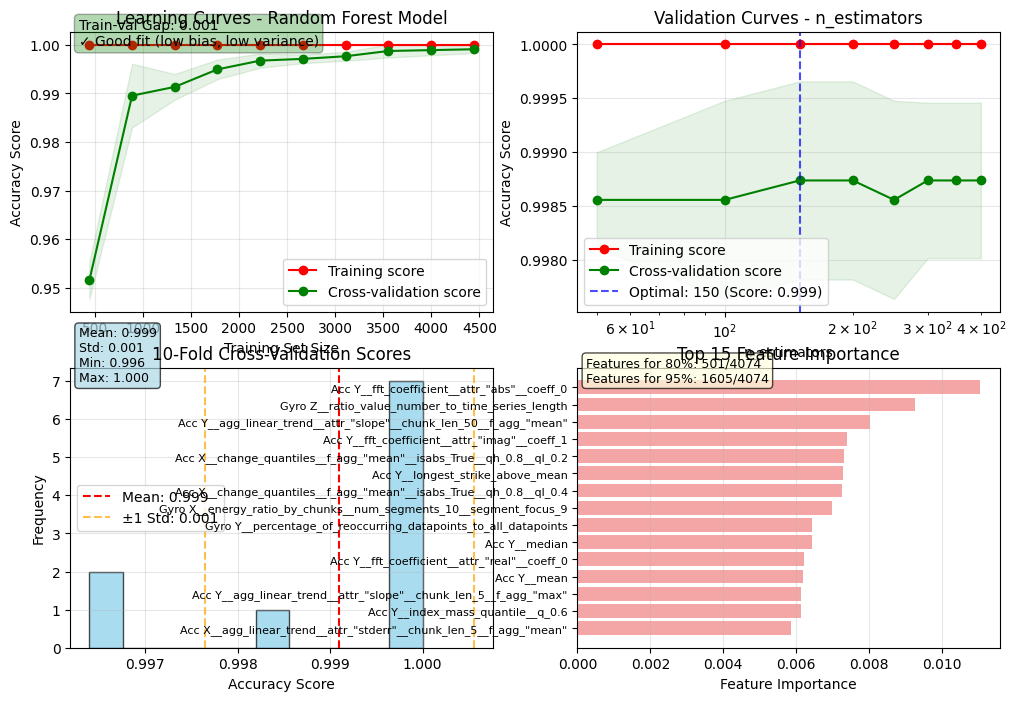

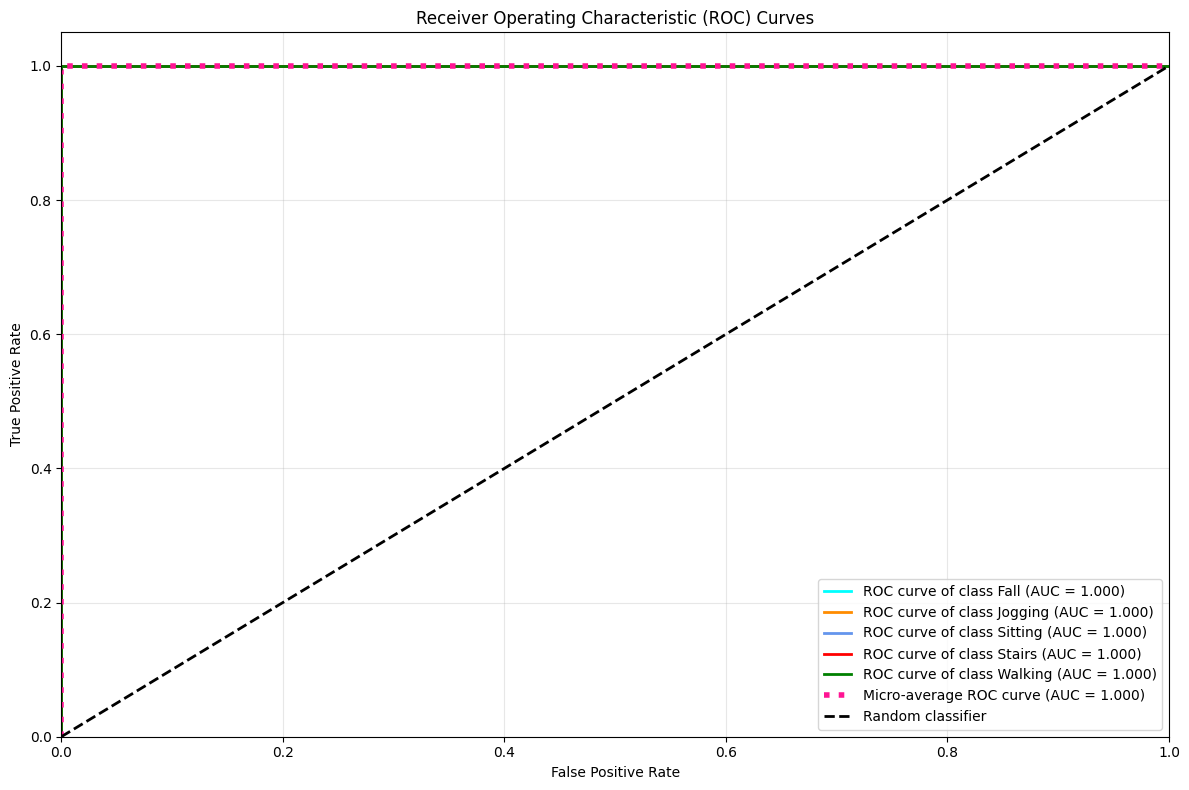

ROC AUC Scores:
  Class Fall: 1.0000
  Class Jogging: 1.0000
  Class Sitting: 1.0000
  Class Stairs: 1.0000
  Class Walking: 1.0000
  Micro-average: 1.0000
  Mean AUC: 1.0000

Analyzing prediction confidence...


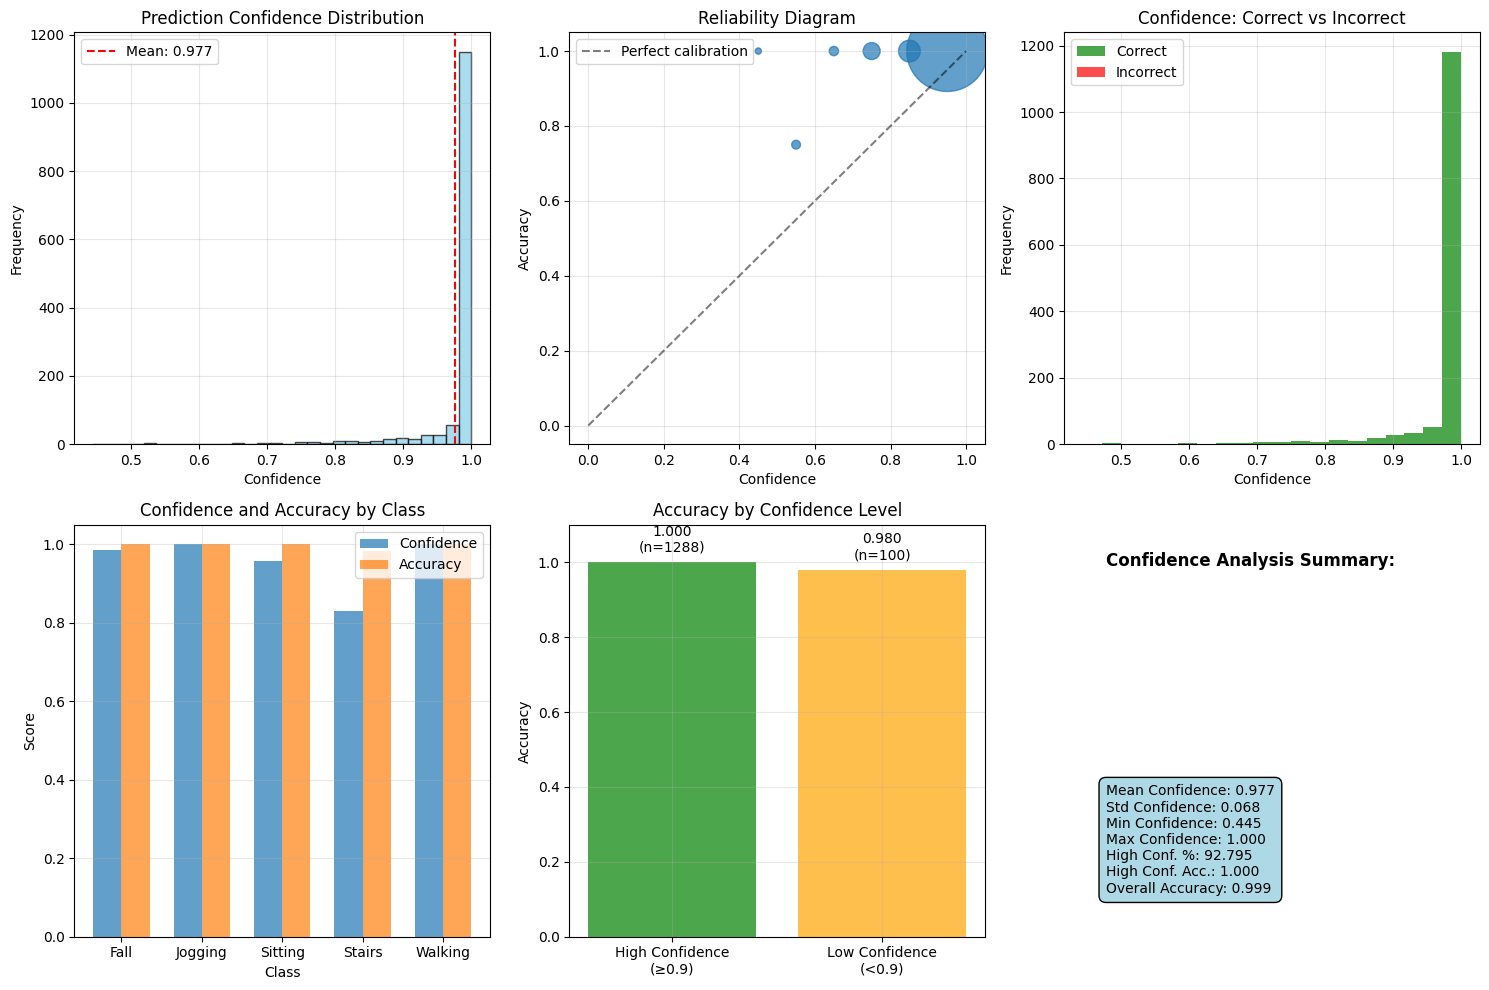

Mean confidence: 0.977
High confidence predictions (≥0.9): 92.8%
High confidence accuracy: 1.000
Overall accuracy: 0.999


<Figure size 640x480 with 0 Axes>


VALIDATION SUMMARY
📊 Learning Curve Analysis:
   Final Training Score: 1.0000
   Final Validation Score: 0.9991
   Train-Validation Gap: 0.0009
   ✅ Excellent fit - No overfitting detected

📈 Cross-Validation Analysis:
   Mean CV Score: 0.9991 (±0.0015)
   CV Score Range: 0.9964 - 1.0000
   Coefficient of Variation: 0.0015
   ✅ Very stable model - Low variance across folds

🎯 Generalization Analysis:
   Training Accuracy: 1.0000
   Test Accuracy: 0.9986
   Generalization Gap: 0.0014
   ✅ Excellent generalization

🏆 OVERALL MODEL ASSESSMENT:
   🌟 EXCELLENT MODEL - Ready for production
   Overall Score: 100/100


In [2]:
result = improve_classification()
    
if result:
        rf_model, X_train_sel, X_test_sel, y_train, y_test, validation_results, uma_results = result
        
        # Try SMOTE approach
        smote_model = try_smote_approach(X_train_sel, y_train, X_test_sel, y_test)
        
        print("\n=== IMPROVEMENT SUMMARY ===")
        print("✓ Improved Random Forest with better hyperparameters")
        print("✓ Better class balancing with 'balanced_subsample'")
        print("✓ Feature selection applied")
        print("✓ Confusion matrices saved as PNG files")
        print("✓ Comprehensive model validation completed")
        print("✓ Learning curves and diagnostic plots generated")
        print("✓ UMA dataset testing completed")
        if uma_results:
            print(f"✓ Cross-dataset testing successful - UMA accuracy: {uma_results['accuracy']:.4f}")
        if smote_model:
            print("✓ SMOTE-based approach also trained")
        print("✓ Models saved for future use")
        
       
        print(f"\n📊 VALIDATION SUMMARY:")
        print(f"   Overall Model Score: {validation_results['overall_score']}/100")
        print(f"   Test Accuracy: {validation_results['test_accuracy']:.4f}")
        print(f"   Generalization Gap: {validation_results['generalization_gap']:.4f}")
        print(f"   CV Score Stability: ±{validation_results['cv_scores'].std():.4f}")
        
        # Save validation results
        import json
        with open('validation_results.json', 'w') as f:
            # Convert numpy arrays to lists for JSON serialization
            results_to_save = {
                'overall_score': validation_results['overall_score'],
                'test_accuracy': validation_results['test_accuracy'],
                'generalization_gap': validation_results['generalization_gap'],
                'learning_curve_gap': validation_results['learning_curve_gap'],
                'cv_scores_mean': float(validation_results['cv_scores'].mean()),
                'cv_scores_std': float(validation_results['cv_scores'].std()),
                'cv_scores': validation_results['cv_scores'].tolist()
            }
            json.dump(results_to_save, f, indent=2)
        print("✓ Validation results saved to 'validation_results.json'")
        
        # Comprehensive model validation
        comprehensive_model_validation(rf_model, X_train_sel, X_test_sel, y_train, y_test, X_train_sel.columns)
